# TC Track Parameters - Furthest Point Analysis
Extract cyclone track parameters and generate synthetic tracks


In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from pyproj import Geod
from scipy.optimize import root_scalar
from bluemath_tk.tcs.tracks import track_triming_circle

geod = Geod(ellps='WGS84')

from utils.tcs_fcts import point_from_center, compute_entrance_exit_azimuth_prolong, mean_translation_velocity, furthest_point_from_entry_exit, travel_time_linear_v, solve_velocity, interpolate_geodesic, integrate_distance


* Data access can be requested to bluemath@unican.es
You can update any path or add new paths with the update_paths function, from bluemath_tk.config.paths.
Example: update_paths({'SHYTCWAVES_COEFS': '/new/path/to/data'})


In [2]:
hist_tracks_nc = xr.open_dataset('/lustre/geocean/WORK/users/alonsoap/personal/MUSCLE_TCS_NC/outputs/tracks_at_7r/hist_tracks_7r_filter.nc')

lon_site = -75.5730
lat_site = 36.0050
RADIUS_DEG = 7
RADIUS_KM = 777


Using Esri World Imagery (ArcGIS):
- Free for public and non-commercial use
- Commercial use allowed under Esri terms of service
- Attribution required: 'Tiles © Esri — Sources: Esri, Earthstar Geographics, CNES/Airbus DS, USDA, USGS, AeroGRID, IGN, and the GIS User Community'
- Max zoom ~19


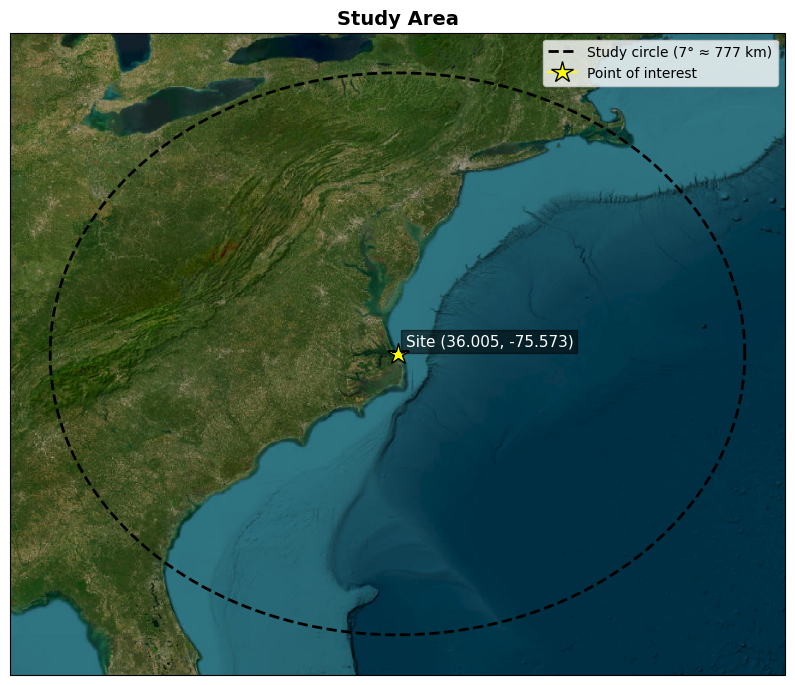

In [3]:
from bluemath_tk.core.plotting.base_plotting import DefaultStaticPlotting

plot = DefaultStaticPlotting()

fig2, ax2 = plt.subplots(figsize=(10, 10), subplot_kw={"projection": ccrs.PlateCarree()})

# Cercle d'étude centré sur le point d'intérêt
angles = np.linspace(0, 2 * np.pi, 361)
circle_lon = lon_site + RADIUS_DEG * np.cos(angles) / np.cos(np.radians(lat_site))
circle_lat = lat_site + RADIUS_DEG * np.sin(angles)

# Définir une zone autour du cercle
lon_min, lon_max = np.nanmin(circle_lon), np.nanmax(circle_lon)
lat_min, lat_max = np.nanmin(circle_lat), np.nanmax(circle_lat)
margin = 1.0
area = [
    lon_min - margin,
    lon_max + margin,
    lat_min - margin,
    lat_max + margin,
]

# Fond de carte satellite
plot.plot_satellite(ax=ax2, source="arcgis", area=area)

# Tracer le cercle et le point d'intérêt
ax2.plot(circle_lon, circle_lat, "k--", lw=2, label=f"Study circle ({RADIUS_DEG}° ≈ {RADIUS_KM} km)")
ax2.plot(lon_site, lat_site, marker="*", color="yellow", markeredgecolor="black", markersize=16, label="Point of interest")

# Annotation du point central
ax2.text(
    lon_site + 0.2,
    lat_site + 0.2,
    f"Site ({lat_site:.3f}, {lon_site:.3f})",
    fontsize=11,
    color="white",
    bbox={"facecolor": "black", "alpha": 0.5, "pad": 3},
)

ax2.set_extent(area, crs=ccrs.PlateCarree())
ax2.set_title("Study Area", fontsize=14, fontweight="bold")
ax2.legend(loc="upper right", fontsize=10)

plt.savefig("figures/Syntesis/01_study_area_circle.png", dpi=200, bbox_inches="tight")
plt.show()

In [4]:
params_list = []
df_full_list, df_small_list = [], []

for i in range(len(hist_tracks_nc['storm'])):
    storm = hist_tracks_nc.isel(storm=i)
    name = f"{storm.name.values.item().decode('utf-8')}_{storm.time.values[0].astype('datetime64[Y]').astype(int) + 1970}"

    df_full = pd.DataFrame({
        'time': storm['time'].values,
        'lat': storm['lat'].values,
        'lon': ((storm['lon'].values + 180) % 360) - 180,
        'pmin': storm['wmo_pres'].values,
        'vmax': storm['wmo_wind'].values
    }).dropna()
    df_full_list.append(df_full.copy())

    df = df_full.drop_duplicates(subset='time').set_index('time')
    df = df.reindex(pd.date_range(df.index.min(), df.index.max(), freq='H')).interpolate()
    df_small = track_triming_circle(df, lon_site, lat_site, RADIUS_DEG)
    df_small_list.append(df_small.copy())

    entr_az, entr_d, exit_az, exit_d = compute_entrance_exit_azimuth_prolong(df_small, lat_site, lon_site)
    fur_idx, fur_dist, fur_az = furthest_point_from_entry_exit(df_small, lat_site, lon_site)
    fur_pos = df_small.index.get_loc(fur_idx)
    
    p_entr, p_fur, p_exit = df_small.iloc[0]['pmin'], df_small.iloc[fur_pos]['pmin'], df_small.iloc[-1]['pmin']

    lon_f, lat_f = df_small.iloc[fur_pos][['lon', 'lat']]

    d12_obs = geod.inv(df_small.iloc[0]['lon'], df_small.iloc[0]['lat'], lon_f, lat_f)[2] / 1000
    d23_obs = geod.inv(lon_f, lat_f, df_small.iloc[-1]['lon'], df_small.iloc[-1]['lat'])[2] / 1000

    v_fur = (mean_translation_velocity(df_small, fur_pos-1, fur_pos) + 
             mean_translation_velocity(df_small, fur_pos, fur_pos+1)) / 2
    t1 = (df_small.index[fur_pos] - df_small.index[0]).total_seconds() / 3600
    t2 = (df_small.index[-1] - df_small.index[fur_pos]).total_seconds() / 3600
    v_entr = solve_velocity(d12_obs, t1, v_fur)
    v_exit = solve_velocity(d23_obs, t2, v_fur)
    
    params_list.append({
        'name': name,
        'date_furthest': df_small.index[fur_pos],
        'azimuth_entrance': entr_az,
        'distance_entrance': entr_d,
        'azimuth_exit': exit_az,
        'distance_exit': exit_d,
        'azimuth_furthest': fur_az,
        'distance_furthest_km': fur_dist,
        'p_furthest_hPa': p_fur,
        'p_entrance_hPa': p_entr,
        'p_exit_hPa': p_exit,
        'vmean_entrance_kmh': v_entr,
        'vmean_furthest_kmh': v_fur,
        'vmean_exit_kmh': v_exit,
    })

print(f"Extraction terminée: {len(params_list)} tracks")


Extraction terminée: 172 tracks


In [5]:
df_synth_list = []

for i, p in enumerate(params_list):
    v_entr, v_fur, v_exit = p['vmean_entrance_kmh'], p['vmean_furthest_kmh'], p['vmean_exit_kmh']
    
    # Skip invalid velocities
    if v_entr <= 0 or v_fur <= 0 or v_exit <= 0:
        df_synth_list.append(None)
        continue

    lat_f, lon_f = point_from_center(lat_site, lon_site, p['azimuth_furthest'], p['distance_furthest_km'])
    lat_e, lon_e = point_from_center(lat_site, lon_site, p['azimuth_entrance'], p['distance_entrance'])
    lat_x, lon_x = point_from_center(lat_site, lon_site, p['azimuth_exit'], p['distance_exit'])

    d_fur_to_entry = geod.inv(lon_f, lat_f, lon_e, lat_e)[2] / 1000
    d_fur_to_exit = geod.inv(lon_f, lat_f, lon_x, lat_x)[2] / 1000

    dt1 = travel_time_linear_v(d_fur_to_entry, v_fur, v_entr)
    dt2 = travel_time_linear_v(d_fur_to_exit, v_fur, v_exit)
    
    if np.isnan(dt1) or np.isnan(dt2):
        df_synth_list.append(None)
        continue

    t1_arr, v1_arr, d1_arr = integrate_distance(v_fur, v_entr, dt1)

    t1_arr, v1_arr, d1_arr = t1_arr[::-1], v1_arr[::-1], d1_arr[-1] - d1_arr[::-1]
    lat1, lon1 = interpolate_geodesic(lat_e, lon_e, lat_f, lon_f, d1_arr)
    
    t2_arr, v2_arr, d2_arr = integrate_distance(v_fur, v_exit, dt2)
    lat2, lon2 = interpolate_geodesic(lat_f, lon_f, lat_x, lon_x, d2_arr)

    p_entr, p_fur, p_exit = p['p_entrance_hPa'], p['p_furthest_hPa'], p['p_exit_hPa']

    n1, n2 = len(t1_arr), len(t2_arr)
    time_index = pd.date_range(
        start=p['date_furthest'] - pd.Timedelta(hours=n1-1),
        periods=n1 + n2 - 1,
        freq='H'
    )
    
    df_synth = pd.DataFrame({
        'lat': np.concatenate([lat1, lat2[1:]]),
        'lon': np.concatenate([lon1, lon2[1:]]),
        'pmin': np.concatenate([np.linspace(p_entr, p_fur, n1), 
                                np.linspace(p_fur, p_exit, n2)[1:]]),
        'vmean': np.concatenate([v1_arr[:-1], [v_fur], v2_arr[1:]])
    }, index=time_index)
    df_synth_list.append(df_synth)

    fig = plt.figure(figsize=(15, 5))
    
    ax1 = plt.subplot(1, 3, 1, projection=ccrs.PlateCarree())
    ax1.add_feature(cfeature.COASTLINE); ax1.add_feature(cfeature.LAND, alpha=0.3)
    ax1.plot(df_full_list[i]['lon'], df_full_list[i]['lat'], 'k-', lw=1, label='Full')
    ax1.plot(df_small_list[i]['lon'], df_small_list[i]['lat'], 'r-', lw=2, label='Obs 7°')
    ax1.plot(df_synth['lon'], df_synth['lat'], 'b--', marker='o', ms=0.5, lw=0.1, label='Synth')
    angles = np.linspace(0, 2 * np.pi, 361)
    ax1.plot(lon_site + RADIUS_DEG * np.cos(angles) / np.cos(np.radians(lat_site)),
             lat_site + RADIUS_DEG * np.sin(angles), 'k--', lw=1)
    ax1.set_title(p['name']); ax1.legend(fontsize=7)
    
    ax2 = plt.subplot(1, 3, 2)
    ax2 = plt.subplot(1, 3, 2)
    ax2.plot(df_small_list[i].index, df_small_list[i]['pmin'].values, 'r-', lw=2, label='Obs')
    ax2.plot(df_synth.index, df_synth['pmin'].values, 'b--', lw=2, label='Synth')
    ax2.axvline(p['date_furthest'], color='green', ls=':', lw=1, label='Furthest')
    ax2.set_ylabel('Pressure (hPa)')
    ax2.legend(); ax2.grid(alpha=0.3)
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    ax3 = plt.subplot(1, 3, 3)
    t_vel_obs = df_small_list[i].index[:-1]  # velocity is between points
    v_obs = [mean_translation_velocity(df_small_list[i], j, j+1) for j in range(len(df_small_list[i])-1)]
    ax3.plot(t_vel_obs, v_obs, 'r-', lw=2, label='Obs')
    ax3.plot(df_synth.index, df_synth['vmean'].values, 'b--', lw=2, label='Synth')
    ax3.axvline(p['date_furthest'], color='green', ls=':', lw=1, label='Furthest')
    ax3.set_ylabel('Velocity (km/h)')
    ax3.legend(); ax3.grid(alpha=0.3)
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    #plt.savefig(f'figures/01_hist_params/storm_{p["name"]}_comparison.png', dpi=200)
    plt.close()

In [6]:
df_params = pd.DataFrame(params_list)
florence = df_params[df_params['name'] == 'FLORENCE_2018']
print(florence)

              name       date_furthest  azimuth_entrance  distance_entrance  \
145  FLORENCE_2018 2018-09-16 18:00:00        148.850834         760.394215   

     azimuth_exit  distance_exit  azimuth_furthest  distance_furthest_km  \
145      15.24567      715.22765        252.355213            631.686997   

     p_furthest_hPa  p_entrance_hPa  p_exit_hPa  vmean_entrance_kmh  \
145          1006.0      947.666687      1006.0            8.141307   

     vmean_furthest_kmh  vmean_exit_kmh  
145           14.886991       47.681457  


Using Esri World Imagery (ArcGIS):
- Free for public and non-commercial use
- Commercial use allowed under Esri terms of service
- Attribution required: 'Tiles © Esri — Sources: Esri, Earthstar Geographics, CNES/Airbus DS, USDA, USGS, AeroGRID, IGN, and the GIS User Community'
- Max zoom ~19


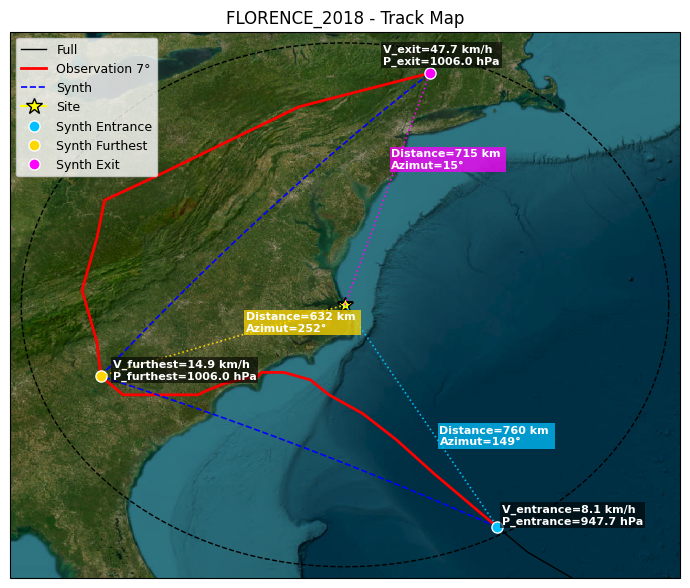

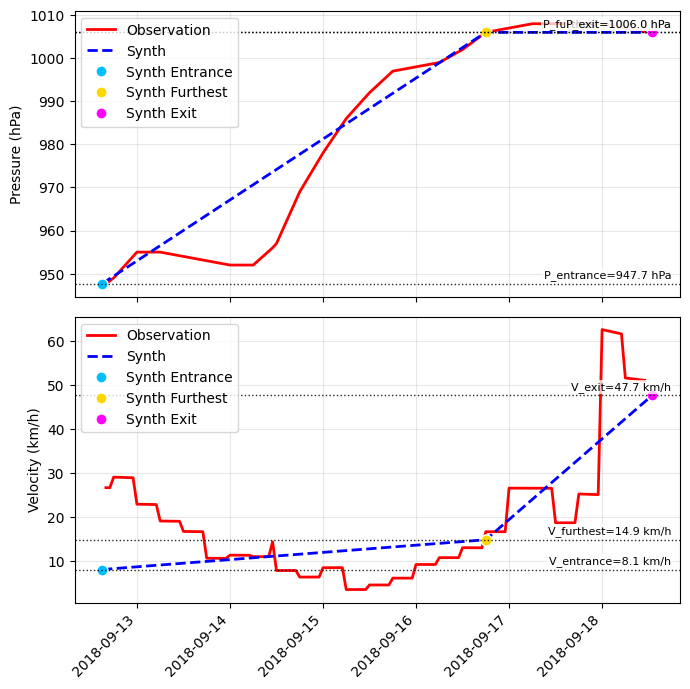

In [16]:
# Get the index of FLORENCE_2018 from params_list
i = next((idx for idx, param in enumerate(params_list) if param['name'] == 'FLORENCE_2018'), None)
if i is None:
    print('FLORENCE_2018 not found in params_list')
else:
    p = florence.iloc[0]  # Extract first row as Series to get scalar values
    v_entr, v_fur, v_exit = p['vmean_entrance_kmh'], p['vmean_furthest_kmh'], p['vmean_exit_kmh']

    lat_f, lon_f = point_from_center(lat_site, lon_site, p['azimuth_furthest'], p['distance_furthest_km'])
    lat_e, lon_e = point_from_center(lat_site, lon_site, p['azimuth_entrance'], p['distance_entrance'])
    lat_x, lon_x = point_from_center(lat_site, lon_site, p['azimuth_exit'], p['distance_exit'])

    d_fur_to_entry = geod.inv(lon_f, lat_f, lon_e, lat_e)[2] / 1000
    d_fur_to_exit = geod.inv(lon_f, lat_f, lon_x, lat_x)[2] / 1000

    dt1 = travel_time_linear_v(d_fur_to_entry, v_fur, v_entr)
    dt2 = travel_time_linear_v(d_fur_to_exit, v_fur, v_exit)

    t1_arr, v1_arr, d1_arr = integrate_distance(v_fur, v_entr, dt1)
    t1_arr, v1_arr, d1_arr = t1_arr[::-1], v1_arr[::-1], d1_arr[-1] - d1_arr[::-1]
    lat1, lon1 = interpolate_geodesic(lat_e, lon_e, lat_f, lon_f, d1_arr)

    t2_arr, v2_arr, d2_arr = integrate_distance(v_fur, v_exit, dt2)
    lat2, lon2 = interpolate_geodesic(lat_f, lon_f, lat_x, lon_x, d2_arr)

    p_entr, p_fur, p_exit = p['p_entrance_hPa'], p['p_furthest_hPa'], p['p_exit_hPa']

    n1, n2 = len(t1_arr), len(t2_arr)
    time_index = pd.date_range(
        start=p['date_furthest'] - pd.Timedelta(hours=n1 - 1),
        periods=n1 + n2 - 1,
        freq='H'
    )

    df_synth = pd.DataFrame({
        'lat': np.concatenate([lat1, lat2[1:]]),
        'lon': np.concatenate([lon1, lon2[1:]]),
        'pmin': np.concatenate([
            np.linspace(p_entr, p_fur, n1),
            np.linspace(p_fur, p_exit, n2)[1:]
        ]),
        'vmean': np.concatenate([v1_arr[:-1], [v_fur], v2_arr[1:]])
    }, index=time_index)

    # Same marker shape, different colors for the three key synthetic points
    synth_markers = {
        'Entrance': {'idx': 0, 'color': '#00BFFF'},
        'Furthest': {'idx': n1 - 1, 'color': '#FFD700'},
        'Exit': {'idx': len(df_synth) - 1, 'color': '#FF00FF'}
    }

    # Attributes to display next to each point on map (figure 1)
    point_attributes = {
        'Entrance': {'v': v_entr, 'p': p_entr},
        'Furthest': {'v': v_fur, 'p': p_fur},
        'Exit': {'v': v_exit, 'p': p_exit}
    }

    # Text offsets near each point on map (decluttered)
    map_attr_offsets = {
        'Entrance': (0.12, 0.08),
        'Furthest': (0.32, -0.08),
        'Exit': (-1.25, 0.25)
    }

    # Distance/azimuth label placement along each segment (decluttered)
    dist_label_cfg = {
        'Entrance': {'t': 0.62, 'dx': 0.00, 'dy': -0.06},
        'Furthest': {'t': 0.42, 'dx': 0.10, 'dy': 0.10},
        'Exit': {'t': 0.58, 'dx': -0.08, 'dy': 0.06}
    }

    # Better label placement for figure 2 annotations
    label_offsets = {
        'Entrance': (10, 10),
        'Furthest': (10, -14),
        'Exit': (-38, 10)
    }

    # Figure 1: map only with satellite + extent around circle
    fig1 = plt.figure(figsize=(7, 7))
    ax1 = fig1.add_subplot(111, projection=ccrs.PlateCarree())

    angles = np.linspace(0, 2 * np.pi, 361)
    circle_lon_plot = lon_site + RADIUS_DEG * np.cos(angles) / np.cos(np.radians(lat_site))
    circle_lat_plot = lat_site + RADIUS_DEG * np.sin(angles)

    circle_margin = 0.3
    circle_lon_min, circle_lon_max = np.nanmin(circle_lon_plot), np.nanmax(circle_lon_plot)
    circle_lat_min, circle_lat_max = np.nanmin(circle_lat_plot), np.nanmax(circle_lat_plot)
    area_map = [
        circle_lon_min - circle_margin,
        circle_lon_max + circle_margin,
        circle_lat_min - circle_margin,
        circle_lat_max + circle_margin,
    ]

    plot.plot_satellite(ax=ax1, source="arcgis", area=area_map)

    ax1.plot(df_full_list[i]['lon'], df_full_list[i]['lat'], 'k-', lw=1, label='Full')
    ax1.plot(df_small_list[i]['lon'], df_small_list[i]['lat'], 'r-', lw=2, label='Observation 7°')
    ax1.plot(df_synth['lon'], df_synth['lat'], 'b--', lw=1.2, label='Synth')

    # Point de référence (site)
    ax1.plot(lon_site, lat_site, marker='*', color='yellow', markeredgecolor='black', markersize=12, label='Site')

    for point_name, point_cfg in synth_markers.items():
        idx_m = point_cfg['idx']
        point_lon = df_synth['lon'].iloc[idx_m]
        point_lat = df_synth['lat'].iloc[idx_m]

        ax1.plot(
            point_lon,
            point_lat,
            marker='o',
            color=point_cfg['color'],
            markeredgecolor='white',
            markersize=8,
            linestyle='None',
            label=f"Synth {point_name}"
        )

        # Segment site -> point
        ax1.plot([lon_site, point_lon], [lat_site, point_lat], linestyle=':', lw=1.2, color=point_cfg['color'], alpha=0.95)

        # Distance et azimut géodésiques depuis le site
        az12, _, dist_m = geod.inv(lon_site, lat_site, point_lon, point_lat)
        az12 = (az12 + 360) % 360
        dist_km = dist_m / 1000.0

        t_factor = dist_label_cfg[point_name]['t']
        text_lon = lon_site + t_factor * (point_lon - lon_site) + dist_label_cfg[point_name]['dx']
        text_lat = lat_site + t_factor * (point_lat - lat_site) + dist_label_cfg[point_name]['dy']
        ax1.text(
            text_lon,
            text_lat,
            f"Distance={dist_km:.0f} km \nAzimut={az12:.0f}°",
            fontsize=8,
            color='white',
            fontweight='bold',
            bbox={'facecolor': point_cfg['color'], 'alpha': 0.75, 'edgecolor': 'none', 'pad': 1.3}
        )

        # V and P attributes next to each point
        dv = map_attr_offsets[point_name]
        point_attr = point_attributes[point_name]
        ax1.text(
            point_lon + dv[0],
            point_lat + dv[1],
            f"V_{point_name.lower()}={point_attr['v']:.1f} km/h\nP_{point_name.lower()}={point_attr['p']:.1f} hPa",
            fontsize=8,
            color='white',
            fontweight='bold',
            bbox={'facecolor': 'black', 'alpha': 0.6, 'edgecolor': 'none', 'pad': 1.4}
        )

    ax1.plot(circle_lon_plot, circle_lat_plot, 'k--', lw=1)
    ax1.set_extent(area_map, crs=ccrs.PlateCarree())
    ax1.set_title(f"{p['name']} - Track Map")
    ax1.legend(fontsize=9, loc="upper left")
    plt.tight_layout()

    # Figure 2: ax2 and ax3 only
    fig2, (ax2, ax3) = plt.subplots(2, 1, figsize=(7, 7))

    ax2.plot(df_small_list[i].index, df_small_list[i]['pmin'].values, 'r-', lw=2, label='Observation')
    ax2.plot(df_synth.index, df_synth['pmin'].values, 'b--', lw=2, label='Synth')
    for point_name, point_cfg in synth_markers.items():
        idx_m = point_cfg['idx']
        x_point = df_synth.index[idx_m]
        y_point = df_synth['pmin'].iloc[idx_m]
        ax2.plot(
            x_point,
            y_point,
            marker='o',
            color=point_cfg['color'],
            markeredgecolor='white',
            markersize=8,
            linestyle='None',
            label=f"Synth {point_name}"
        )
        p_level = point_attributes[point_name]['p']
        ax2.axhline(y=p_level, color='black', ls=':', lw=1, alpha=0.85)
        ax2.annotate(
            f"P_{point_name.lower()}={p_level:.1f} hPa",
            xy=(0.99, p_level),
            xycoords=('axes fraction', 'data'),
            xytext=(-2, 2),
            textcoords='offset points',
            ha='right',
            va='bottom',
            fontsize=8,
            color='black',
            bbox={'facecolor': 'white', 'alpha': 0.75, 'edgecolor': 'none', 'pad': 1.2}
        )
    ax2.set_ylabel('Pressure (hPa)')
    ax2.legend(loc="upper left")
    ax2.grid(alpha=0.3)
    ax2.tick_params(axis='x', labelbottom=False)

    t_vel_obs = df_small_list[i].index[:-1]
    v_obs = [mean_translation_velocity(df_small_list[i], j, j + 1) for j in range(len(df_small_list[i]) - 1)]
    ax3.plot(t_vel_obs, v_obs, 'r-', lw=2, label='Observation')
    ax3.plot(df_synth.index, df_synth['vmean'].values, 'b--', lw=2, label='Synth')
    for point_name, point_cfg in synth_markers.items():
        idx_m = point_cfg['idx']
        x_point = df_synth.index[idx_m]
        y_point = df_synth['vmean'].iloc[idx_m]
        ax3.plot(
            x_point,
            y_point,
            marker='o',
            color=point_cfg['color'],
            markeredgecolor='white',
            markersize=8,
            linestyle='None',
            label=f"Synth {point_name}"
        )
        v_level = point_attributes[point_name]['v']
        ax3.axhline(y=v_level, color='black', ls=':', lw=1, alpha=0.85)
        ax3.annotate(
            f"V_{point_name.lower()}={v_level:.1f} km/h",
            xy=(0.99, v_level),
            xycoords=('axes fraction', 'data'),
            xytext=(-2, 2),
            textcoords='offset points',
            ha='right',
            va='bottom',
            fontsize=8,
            color='black',
            bbox={'facecolor': 'white', 'alpha': 0.75, 'edgecolor': 'none', 'pad': 1.2}
        )
    ax3.set_ylabel('Velocity (km/h)')
    ax3.legend(loc="upper left")
    ax3.grid(alpha=0.3)
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

    plt.tight_layout()

In [ ]:
df_params = pd.DataFrame(params_list)
df_params['bmus'] = hist_tracks_nc['bmus'].values
#df_params.to_csv('outputs/hist_tracks_7r_params.csv', index=False)
df_params.head()


,name,date_furthest,azimuth_entrance,distance_entrance,azimuth_exit,distance_exit,azimuth_furthest,distance_furthest_km,p_furthest_hPa,p_entrance_hPa,p_exit_hPa,vmean_entrance_kmh,vmean_furthest_kmh,vmean_exit_kmh,bmus
0,GERT_1981,1981-09-12 06:00:00,144.577111,777.409262,114.981312,778.762420,118.798681,758.371069,990.0,988.000000,990.666687,30.767686,26.393547,28.625592,6
1,UNNAMED_1981,1981-11-13 18:00:00,164.809081,574.015182,47.943484,769.925676,122.867272,552.054640,995.0,1004.000000,982.333313,17.305947,10.190970,13.432885,21
2,UNNAMED_1982,1982-06-19 06:00:00,221.903226,736.561023,49.478402,710.329099,221.700782,309.676951,992.0,993.166687,991.333313,30.027733,35.817289,76.422727,24
3,DEAN_1983,1983-09-29 00:00:00,158.063269,773.214402,331.060320,241.230427,109.636774,465.295141,1003.0,1003.000000,1015.000000,28.768715,7.852407,27.999378,31
4,DIANA_1984,1984-09-14 00:00:00,215.295295,771.902862,55.282280,773.707819,240.501169,308.470328,1003.0,993.666687,992.000000,3.980744,8.090314,66.488446,16


In [ ]:
valid_synth = [(i, df) for i, df in enumerate(df_synth_list) if df is not None]
max_len = max(len(df) for _, df in valid_synth)

def pad_array(arr, length):
    out = np.full(length, np.nan)
    out[:len(arr)] = arr
    return out

ds = xr.Dataset(
    data_vars={
        'lat': (['storm', 'time'], [pad_array(df['lat'].values, max_len) for _, df in valid_synth]),
        'lon': (['storm', 'time'], [pad_array(df['lon'].values, max_len) for _, df in valid_synth]),
        'pmin': (['storm', 'time'], [pad_array(df['pmin'].values, max_len) for _, df in valid_synth]),
    },
    coords={
        'storm': [df_params.iloc[i]['name'] for i, _ in valid_synth],
        'date': ('storm', [str(df_synth_list[i].index[0]) for i, _ in valid_synth]),
        'time': np.arange(max_len),
    },
    attrs={'description': 'Historic TC tracks'}
)
ds.to_netcdf('outputs/hist_tracks_7r.nc')
print(ds)


<xarray.Dataset> Size: 1MB
Dimensions:  (storm: 172, time: 289)
Coordinates:
  * storm    (storm) <U14 10kB 'GERT_1981' 'UNNAMED_1981' ... 'WANDA_2021'
  * time     (time) int64 2kB 0 1 2 3 4 5 6 7 ... 282 283 284 285 286 287 288
    date     (storm) <U19 13kB '1981-09-11 18:00:00' ... '2021-10-25 17:00:00'
Data variables:
    lat      (storm, time) float64 398kB 30.2 30.41 30.61 30.82 ... nan nan nan
    lon      (storm, time) float64 398kB -70.9 -70.69 -70.48 ... nan nan nan
    pmin     (storm, time) float64 398kB 988.0 988.2 988.3 988.5 ... nan nan nan
Attributes:
    description:  Historic TC tracks


Using Esri World Imagery (ArcGIS):
- Free for public and non-commercial use
- Commercial use allowed under Esri terms of service
- Attribution required: 'Tiles © Esri — Sources: Esri, Earthstar Geographics, CNES/Airbus DS, USDA, USGS, AeroGRID, IGN, and the GIS User Community'
- Max zoom ~19


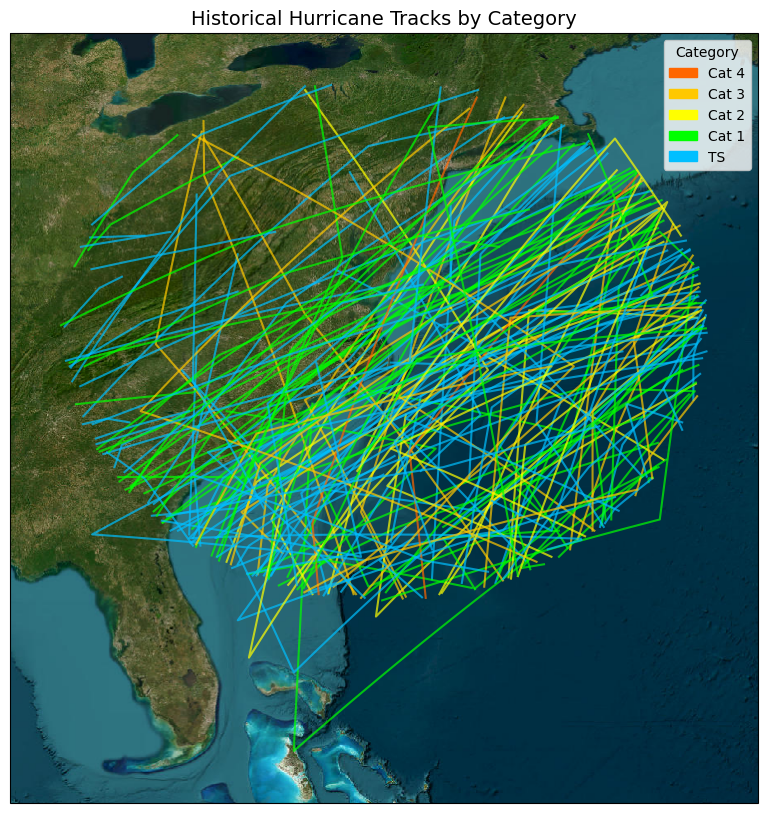

In [ ]:
from bluemath_tk.core.plotting.base_plotting import DefaultStaticPlotting
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs

# Définir les catégories et couleurs (échelle Saffir-Simpson)
def get_category_color(p_hPa):
    """Retourne la couleur et le nom de catégorie selon la pression."""
    if p_hPa < 920:
        return '#FF0000', 'CATS'      # Rouge vif
    elif p_hPa < 944:
        return '#FF6600', 'Cat 4'      # Orange foncé
    elif p_hPa < 964:
        return '#FFC800', 'Cat 3'      # Orange/Jaune
    elif p_hPa < 979:
        return '#FFFF00', 'Cat 2'      # Jaune
    elif p_hPa < 1000:
        return '#00FF00', 'Cat 1'      # Vert
    else:
        return '#00BFFF', 'TS'         # Bleu clair

# Couleurs pour la légende
category_colors = {
    'Cat 5': '#FF0000',
    'Cat 4': '#FF6600',
    'Cat 3': '#FFC800',
    'Cat 2': '#FFFF00',
    'Cat 1': '#00FF00',
    'TS': '#00BFFF',
}

plot = DefaultStaticPlotting()

fig2, ax2 = plt.subplots(figsize=(10, 10), subplot_kw={"projection": ccrs.PlateCarree()})

# Stocker les catégories présentes pour la légende
categories_present = set()

for i, p in enumerate(params_list):
    v_entr, v_fur, v_exit = p['vmean_entrance_kmh'], p['vmean_furthest_kmh'], p['vmean_exit_kmh']
    
    if v_entr <= 0 or v_fur <= 0 or v_exit <= 0:
        continue

    lat_f, lon_f = point_from_center(lat_site, lon_site, p['azimuth_furthest'], p['distance_furthest_km'])
    lat_e, lon_e = point_from_center(lat_site, lon_site, p['azimuth_entrance'],  p['distance_entrance'])
    lat_x, lon_x = point_from_center(lat_site, lon_site, p['azimuth_exit'], p['distance_exit'])

    d_fur_to_entry = geod.inv(lon_f, lat_f, lon_e, lat_e)[2] / 1000
    d_fur_to_exit = geod.inv(lon_f, lat_f, lon_x, lat_x)[2] / 1000

    dt1 = travel_time_linear_v(d_fur_to_entry, v_fur, v_entr)
    dt2 = travel_time_linear_v(d_fur_to_exit, v_fur, v_exit)
    
    if np.isnan(dt1) or np.isnan(dt2):
        continue

    t1_arr, v1_arr, d1_arr = integrate_distance(v_fur, v_entr, dt1)
    t1_arr, v1_arr, d1_arr = t1_arr[::-1], v1_arr[::-1], d1_arr[-1] - d1_arr[::-1]
    lat1, lon1 = interpolate_geodesic(lat_e, lon_e, lat_f, lon_f, d1_arr)
    
    t2_arr, v2_arr, d2_arr = integrate_distance(v_fur, v_exit, dt2)
    lat2, lon2 = interpolate_geodesic(lat_f, lon_f, lat_x, lon_x, d2_arr)

    p_entr, p_fur, p_exit = p['p_entrance_hPa'], p['p_furthest_hPa'], p['p_exit_hPa']

    n1, n2 = len(t1_arr), len(t2_arr)
    time_index = pd.date_range(
        start=p['date_furthest'] - pd.Timedelta(hours=n1-1),
        periods=n1 + n2 - 1,
        freq='H'
    )
    
    df_synth = pd.DataFrame({
        'lat': np.concatenate([lat1, lat2[1:]]),
        'lon': np.concatenate([lon1, lon2[1:]]),
        'pmin': np.concatenate([np.linspace(p_entr, p_fur, n1), 
                                np.linspace(p_fur, p_exit, n2)[1:]]),
        'vmean': np.concatenate([v1_arr[:-1], [v_fur], v2_arr[1:]])
    }, index=time_index)
    
    # Couleur basée sur p_furthest
    pp = np.min((p_entr, p_fur, p_exit))
    color, cat_name = get_category_color(pp)
    categories_present.add(cat_name)
    
    ax2.plot(df_synth['lon'], df_synth['lat'], color=color, lw=1.5, alpha=0.7)

ax2.autoscale()
extent = ax2.get_extent(crs=ccrs.PlateCarree())

margin = 0.5
area = [
    extent[0] - margin,
    extent[1] + margin,
    extent[2] - margin,
    extent[3] + margin,
]

plot.plot_satellite(ax=ax2, source="arcgis", area=area)

# Légende (seulement les catégories présentes, dans l'ordre)
legend_order = ['CATS', 'Cat 4', 'Cat 3', 'Cat 2', 'Cat 1', 'TS']
handles = [
    mpatches.Patch(color=category_colors[cat], label=cat)
    for cat in legend_order if cat in categories_present
]
ax2.legend(handles=handles, loc='upper right', fontsize=10, title='Category')

ax2.set_extent(area, crs=ccrs.PlateCarree())
plt.title("Historical Hurricane Tracks by Category", fontsize=14)
plt.savefig('figures/Syntesis/01_historical_hurricane_tracks_categories.png', dpi=200)